In [29]:
# ===============================
# URDU SENTENCE SEGMENTATION NOTEBOOK
# ===============================

# Imports
import pandas as pd
import re
import string
import random
import matplotlib.pyplot as plt
import seaborn as sns
from urduhack.tokenization import sentence_tokenizer
from urduhack.preprocessing import normalize_whitespace
import stanza
from IPython.display import display, HTML

In [30]:
# ===============================
# LOAD DATA
# ===============================
file_path = "../data/raw/urdu_tweets.xlsx"
df = pd.read_excel(file_path)
df = df[['Text']].rename(columns={'Text':'text'})

In [31]:
# ===============================
# PREPROCESSING FUNCTION
# ===============================
def preprocess(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"@\w+|#\w+", "", text)
    text = re.sub(r"\bRT\b", "", text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(preprocess)
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)

# Save cleaned data
df.to_csv("../data/processed/urdu_tweets_cleaned.csv", index=False)

In [32]:
# ===============================
# SENTENCE SEGMENTATION ALGORITHMS
# ===============================

# 1. Rule-Based
def split_rule_based(text):
    sentences = re.split(r'۔|\?|!', text)
    sentences = [s.strip() for s in sentences if s.strip() != '']
    return sentences
df['sent_rule'] = df['clean_text'].apply(split_rule_based)

In [33]:
# 2. UrduHack
def split_urduhack(text):
    text = normalize_whitespace(text)
    sentences = sentence_tokenizer(text)
    sentences = [s.strip() for s in sentences if s.strip() != '']
    return sentences
df['sent_urduhack'] = df['clean_text'].apply(split_urduhack)

In [34]:
# 3. Stanza (run on sample only for speed)
stanza.download('ur')
stanza_nlp = stanza.Pipeline(lang='ur', processors='tokenize', tokenize_no_ssplit=False)
sample_df = df.sample(50, random_state=42).reset_index(drop=True)
def split_stanza(text):
    doc = stanza_nlp(text)
    return [s.text.strip() for s in doc.sentences if s.text.strip() != '']
sample_df['sent_stanza'] = sample_df['clean_text'].apply(split_stanza)

2026-03-29 13:32:07 INFO: Downloaded file to C:\Users\Mishi\AppData\Local\StanfordNLP\stanza\Cache\1.11.0\resources\resources.json
2026-03-29 13:32:07 INFO: Downloading default packages for language: ur (Urdu) ...
2026-03-29 13:32:08 INFO: File exists: C:\Users\Mishi\AppData\Local\StanfordNLP\stanza\Cache\1.11.0\resources\ur\default.zip
2026-03-29 13:32:11 INFO: Finished downloading models and saved to C:\Users\Mishi\AppData\Local\StanfordNLP\stanza\Cache\1.11.0\resources
2026-03-29 13:32:11 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2026-03-29 13:32:12 INFO: Downloaded file to C:\Users\Mishi\AppData\Local\StanfordNLP\stanza\Cache\1.11.0\resources\resources.json
2026-03-29 13:32:12 INFO: Loading these models for language: ur (Urdu):
| Processor | Package |
-----------------------
| tokenize  | udtb    |

2026-03-29 13:32:12 INFO: Using d

In [35]:
# 4. Regex Advanced
def split_regex(text):
    sentences = re.split(r'۔+|\?+|!+|(\n)+', text)
    sentences = [s.strip() for s in sentences if s and s.strip() != '']
    return sentences
df['sent_regex'] = df['clean_text'].apply(split_regex)
sample_df['sent_regex'] = sample_df['clean_text'].apply(split_regex)

In [36]:
# 5. Hybrid (Rule + UrduHack)
def split_hybrid(text):
    sents_uh = split_urduhack(text)
    final_sents = []
    for sent in sents_uh:
        final_sents.extend(split_rule_based(sent))
    return final_sents
df['sent_hybrid'] = df['clean_text'].apply(split_hybrid)
sample_df['sent_hybrid'] = sample_df['clean_text'].apply(split_hybrid)

C:\Windows\Temp\ipykernel_7976\2986830315.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(avg_sents.keys()), y=list(avg_sents.values()), palette="viridis")


Plot saved at: ../results\sentence_segmentation_comparison.png


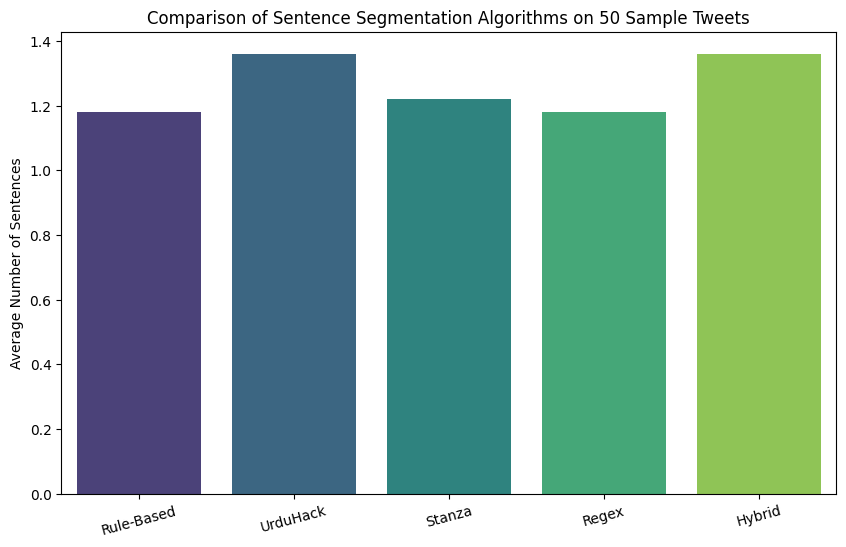

In [40]:
# ===============================
# COMPARISON: AVG SENTENCES PER ALGO
# ===============================
import os

# Ensure results folder exists
results_folder = "../results"
os.makedirs(results_folder, exist_ok=True)

algorithms = {
    "Rule-Based": 'sent_rule',
    "UrduHack": 'sent_urduhack',
    "Stanza": 'sent_stanza',
    "Regex": 'sent_regex',
    "Hybrid": 'sent_hybrid'
}

avg_sents = {name: sample_df[col].apply(len).mean() for name, col in algorithms.items()}

plt.figure(figsize=(10,6))
sns.barplot(x=list(avg_sents.keys()), y=list(avg_sents.values()), palette="viridis")
plt.ylabel("Average Number of Sentences")
plt.title("Comparison of Sentence Segmentation Algorithms on 50 Sample Tweets")
plt.xticks(rotation=15)

# Save the figure in results folder
plot_path = os.path.join(results_folder, "sentence_segmentation_comparison.png")
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
print(f"Plot saved at: {plot_path}")

plt.show()

In [38]:
# ===============================
# AUTOMATIC LIMITATIONS & IMPROVEMENTS REPORT
# ===============================
limitations = {
    'sent_rule': [
        "Fails when punctuation is missing",
        "Cannot handle abbreviations or emojis",
        "Splits incorrectly if multiple punctuations used"
    ],
    'sent_urduhack': [
        "May miss informal sentence breaks",
        "Trained mostly on standard text, less accurate on noisy tweets"
    ],
    'sent_stanza': [
        "ML-based, may fail on unseen patterns",
        "Sensitive to tweet noise and special characters"
    ],
    'sent_regex': [
        "Over-splits when multiple punctuations occur together",
        "Cannot understand context, just pattern matching"
    ],
    'sent_hybrid': [
        "Combines weaknesses of both methods",
        "May over-segment due to cascading splits"
    ]
}

improvements = {
    'sent_rule': "Incorporate ML-based sentence boundary detection or hybrid models with context awareness",
    'sent_urduhack': "Fine-tune UrduHack model on noisy tweet dataset",
    'sent_stanza': "Train custom Stanza model on social media text",
    'sent_regex': "Combine with ML context-based detection to avoid over-splitting",
    'sent_hybrid': "Carefully tune rules and combine with tweet-specific ML model"
}

report = pd.DataFrame({
    'Algorithm': list(limitations.keys()),
    'Limitations': [", ".join(v) for v in limitations.values()],
    'Suggested Improvements': [improvements[k] for k in limitations.keys()]
})
display(report)
report.to_csv("../data/processed/segmentation_limitations_report.csv", index=False)

,Algorithm,Limitations,Suggested Improvements
0,sent_rule,"Fails when punctuation is missing, Cannot hand...",Incorporate ML-based sentence boundary detecti...
1,sent_urduhack,"May miss informal sentence breaks, Trained mos...",Fine-tune UrduHack model on noisy tweet dataset
2,sent_stanza,"ML-based, may fail on unseen patterns, Sensiti...",Train custom Stanza model on social media text
3,sent_regex,Over-splits when multiple punctuations occur t...,Combine with ML context-based detection to avo...
4,sent_hybrid,"Combines weaknesses of both methods, May over-...",Carefully tune rules and combine with tweet-sp...


In [39]:
# ===============================
# EXAMPLES & VISUAL COMPARISON
# ===============================
def color_sentences(sentences, color_palette):
    colored_html = ""
    for i, sent in enumerate(sentences):
        color = color_palette[i % len(color_palette)]
        colored_html += f'<span style="background-color:{color}; padding:2px; margin:2px; display:inline-block;">{sent}</span> '
    return colored_html

colors = ["#FFCCCC", "#CCFFCC", "#CCCCFF", "#FFFFCC", "#FFCCFF", "#CCFFFF"]
num_tweets = 5
example_indices = random.sample(range(len(sample_df)), num_tweets)

for idx in example_indices:
    row = sample_df.loc[idx]
    display(HTML(f"<h4>Original Tweet:</h4><p>{row['clean_text']}</p>"))
    html_table = "<table style='width:100%; border-collapse:collapse;'><tr>"
    for algo in algorithms.values():
        html_table += f"<td style='vertical-align:top; border:1px solid black; padding:5px;'><b>{algo}</b><br>"
        html_table += color_sentences(row[algo], colors)
        html_table += "</td>"
    html_table += "</tr></table><br><hr>"
    display(HTML(html_table))

sent_ruleامیر شادی کرتا ہے ہنی مُون پر چلا جاتاہے جبکہ غریب کے پیچھے5 ماہ ٹینٹ والا پڑا رہتا 20 پلیٹیں 6 چمچے 3 جگ پورے کروا استاد😜😂 عابی مارخورز,sent_urduhackامیر شادی کرتا ہے ہنی مُون پر چلا جاتاہے جبکہ غریب کے پیچھے5 ماہ ٹینٹ والا پڑا رہتا 20 پلیٹیں 6 چمچے 3 جگ پورے کروا استاد😜😂 عابی مارخورز,sent_stanzaامیر شادی کرتا ہے ہنی مُون پر چلا جاتاہے جبکہ غریب کے پیچھے5 ماہ ٹینٹ والا پڑا رہتا 20 پلیٹیں 6 چمچے 3 جگ پورے کروا استاد😜😂 عابی مارخورز,sent_regexامیر شادی کرتا ہے ہنی مُون پر چلا جاتاہے جبکہ غریب کے پیچھے5 ماہ ٹینٹ والا پڑا رہتا 20 پلیٹیں 6 چمچے 3 جگ پورے کروا استاد😜😂 عابی مارخورز,sent_hybridامیر شادی کرتا ہے ہنی مُون پر چلا جاتاہے جبکہ غریب کے پیچھے5 ماہ ٹینٹ والا پڑا رہتا 20 پلیٹیں 6 چمچے 3 جگ پورے کروا استاد😜😂 عابی مارخورز


sent_ruleکیا جڑ سے اکھاڑو گی😜,sent_urduhackکیا جڑ سے اکھاڑو گی😜,sent_stanzaکیا جڑ سے اکھاڑو گی😜,sent_regexکیا جڑ سے اکھاڑو گی😜,sent_hybridکیا جڑ سے اکھاڑو گی😜


sent_ruleپریوں کے کنٹرولر 😄,sent_urduhackپریوں کے کنٹرولر 😄,sent_stanzaپریوں کے کنٹرولر 😄,sent_regexپریوں کے کنٹرولر 😄,sent_hybridپریوں کے کنٹرولر 😄


sent_ruleاچھا لالا 😞,sent_urduhackاچھا لالا ۔,sent_stanzaاچھا لالا ۔۔۔ 😞,sent_regexاچھا لالا 😞,sent_hybridاچھا لالا


sent_ruleاخلاق بیسٹ کر لیں بس😍,sent_urduhackاخلاق بیسٹ کر لیں بس😍,sent_stanzaاخلاق بیسٹ کر لیں بس😍,sent_regexاخلاق بیسٹ کر لیں بس😍,sent_hybridاخلاق بیسٹ کر لیں بس😍
